# 01 Data Exploration
Load the ALOHA dataset, inspect episodes, check camera views, and verify 14-DoF to 7-DoF isolation.

In [2]:
import sys
import os
import sys
sys.path.append(os.path.abspath('..'))

import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from src.data_utils import load_aloha_dataset, extract_single_arm_action

## 1. Load Dataset and Inspect Anatomy
Let's see how many episodes we have and what the features (columns) are.

In [ ]:
# Load dataset
dataset = load_aloha_dataset()
train_data = dataset

# Print basic info
print("Dataset Split:", train_data)

# The episodes are structured continuously in the dataset. Let's group them by `episode_index`
# Since LeRobotDataset loads slowly when we iterate, we can query its metadata
unique_episodes = list(range(train_data.num_episodes))
print(f"Total number of episodes: {len(unique_episodes)}")
print(f"Total number of frames across all episodes: {len(train_data)}")
print("\nFeatures available in each frame:")
for feature_name, feature_type in train_data.features.items():
    print(f" - {feature_name}: {feature_type}")

README.md: 0.00B [00:00, ?B/s]

data/chunk-000/file-000.parquet:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

data/chunk-000/file-001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

data/chunk-000/file-002.parquet:   0%|          | 0.00/187k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Dataset Split: DatasetDict({
    train: Dataset({
        features: ['observation.state', 'action', 'episode_index', 'frame_index', 'timestamp', 'next.done', 'index', 'task_index'],
        num_rows: 20000
    })
})
Total number of episodes: 50
Total number of frames across all episodes: 20000

Features available in each frame:
 - observation.state: List(Value('float32'))
 - action: List(Value('float32'))
 - episode_index: Value('int64')
 - frame_index: Value('int64')
 - timestamp: Value('float32')
 - next.done: Value('bool')
 - index: Value('int64')
 - task_index: Value('int64')


## 2. Inspect Actions and Camera Views
We'll take a look at the action tensor shapes, verify whether language instructions are present, and checkout the images from the available camera view(s).

In [4]:
# Pick a random sample from episode 0
sample_idx = 0
sample = train_data[sample_idx]

# Check action tensor
full_action = sample['action']
print(f"Full action shape: {len(full_action)}")
print(f"Full action values: {full_action}")

single_arm_action = extract_single_arm_action(full_action)
print(f"Single-arm (7-DoF) action shape: {len(single_arm_action)}")
print(f"Single-arm action values: {single_arm_action}")

# Check language
if 'language_instruction' in sample:
    print(f"Language instruction: {sample['language_instruction']}")
else:
    print("Language instruction: NONE (we will proceed with visual-only features)")

# Show an image from the dataset
# Usually ALOHA has 'top', 'camera_0', etc. Let's see what image keys we have.
image_keys = [k for k in sample.keys() if 'image' in k]
print(f"Camera views available: {image_keys}")

if len(image_keys) > 0:
    view_name = image_keys[0]
    img = sample[view_name]
    plt.figure(figsize=(6, 4))
    plt.imshow(img)
    plt.title(f"Sample Frame ({view_name})")
    plt.axis('off')
    plt.show()

Full action shape: 14
Full action values: [-0.013805827125906944, -0.9295923709869385, 1.179631233215332, -0.003067961661145091, -0.3298058807849884, -0.0015339808305725455, 0.1636791080236435, 0.010737866163253784, -0.9295923709869385, 1.2026410102844238, -0.0015339808305725455, -0.3190680146217346, 0.015339808538556099, 0.18998171389102936]
Single-arm (7-DoF) action shape: 7
Single-arm action values: [-0.013805827125906944, -0.9295923709869385, 1.179631233215332, -0.003067961661145091, -0.3298058807849884, -0.0015339808305725455, 0.1636791080236435]
Language instruction: NONE (we will proceed with visual-only features)
Camera views available: []


## 3. Episode Length and Action Distributions
Let's see how long these demonstrations are and what the distributions of the isolated 7-DoF actions look like.

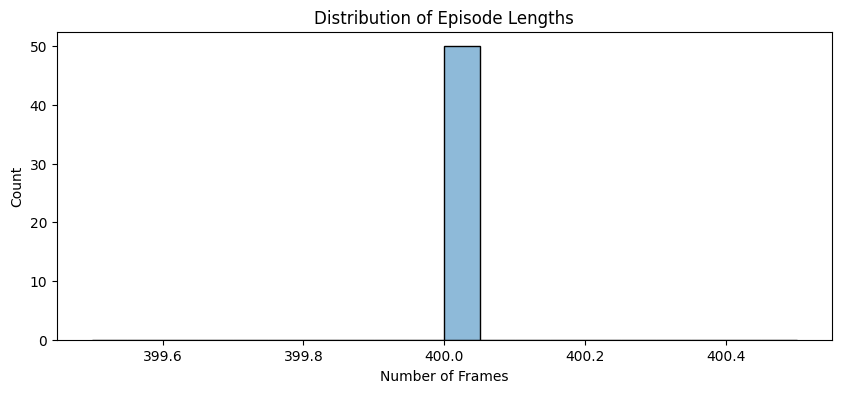

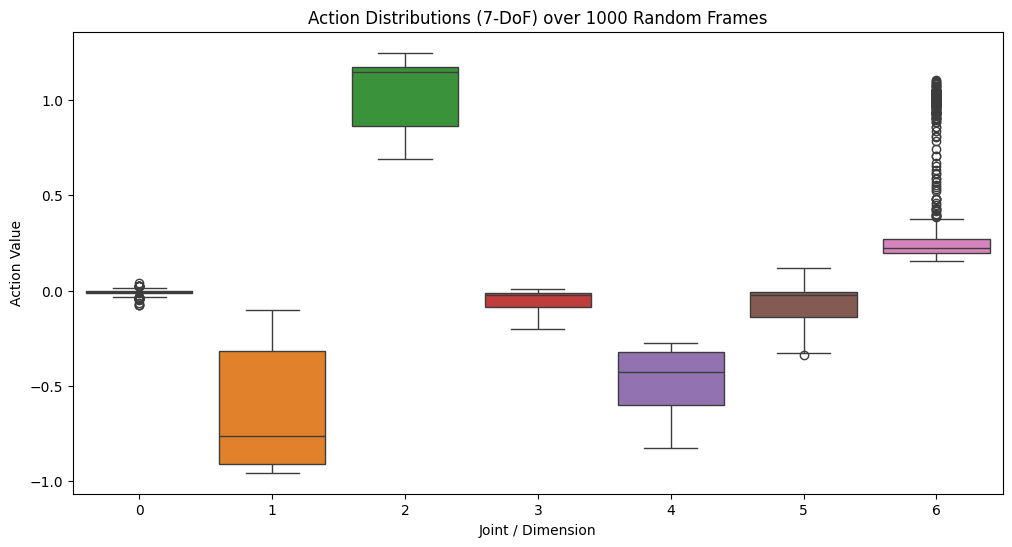

In [ ]:
import numpy as np
# Compute episode lengths
episode_lengths = []
for ep in unique_episodes:
    # Get length from dict
    length = train_data.episode_data_index['to'][ep].item() - train_data.episode_data_index['from'][ep].item()
    episode_lengths.append(length)

plt.figure(figsize=(10, 4))
sns.histplot(episode_lengths, bins=20, kde=True)
plt.title("Distribution of Episode Lengths")
plt.xlabel("Number of Frames")
plt.ylabel("Count")
plt.show()

# Sample actions
sampled_actions = []
sample_indices = np.random.choice(len(train_data), min(1000, len(train_data)), replace=False)
for idx in sample_indices:
    act = extract_single_arm_action(train_data[int(idx)]['action'])
    sampled_actions.append(act)

sampled_actions = np.array(sampled_actions) # shape: (1000, 7)

plt.figure(figsize=(12, 6))
sns.boxplot(data=sampled_actions)
plt.title("Action Distributions (7-DoF) over 1000 Random Frames")
plt.xlabel("Joint / Dimension")
plt.ylabel("Action Value")
plt.show()